# Objetivo 1: instalar y correr MAFFT y HMMER

### a-d) corra todos los comandos anteriores y analice un poco el archivo “secuencias_modelo.hmm”, puede identificar en él los parámetros que usted conoce debe poseer el modelo (probabilidad de emisión de cada residuo en cada columna (estado match), columnas importantes, probabilidad de inserción, etc).

In [13]:
from Bio import AlignIO

input_handle = open("Archivos/PF11563.alignment.seed", "r")
output_handle = open("Archivos/seed.fasta", "w")

alignments = AlignIO.parse(input_handle, "stockholm")
AlignIO.write(alignments, output_handle, "fasta")

input_handle.close()
output_handle.close()

![Dominios Blast](Img/Ej1_HMM.jpg)

![Dominios Blast](Img/Ej1_Pos93.jpg)
Al inspeccionar el archivo, se pueden identificar los parámetros mas importantes del modelo:  
- $\textbf{Columnas importantes:}$ El parámetro LENG 157 indica que el perfil consta de 157 posiciones conservadas y NSEQ 62 confirma que las 62 secuencias del alineamiento semilla fueron utilizadas para entrenar el perfil del HMM.
- $\textbf{Probabilidad de Match:}$ La primera línea de cada posición nos da la probabilidad de encontrar cada uno de los 20 aminoácidos. Por ejemplo, en la posición 93, la Histidina presenta un valor extremadamente bajo de 0.71087, reflejando una altísima conservación biológica en esa columna.
- $\textbf{Probabilidad de Inserción:}$ La segunda línea de cada posición define la probabilidad de que se emita cada aminoácido en caso de ocurrir una inserción en esa posición puntual.  
- $\textbf{Transiciones:}$ La tercera línea de cada bloque establece las probabilidades de pasar de un estado a otro, ya sea manteniendo la coincidencia, abriendo un gap o introduciendo una inserción.

### e) analice el archivo de salida de HMMsearch, trate de identificar dónde están los resultados obtenidos para cada secuencia query, y de ellos donde está el E-value, la cobertura, etc.

Al inspeccionar el archivo de salida generado por hmmsearch, se identifican dos secciones principales de resultados, __"Scores for complete sequences"__ y __"Domain annotation for each sequence"__. A modo de ejemplo, se puede analizar la proteína tr|G0RZQ1|G0RZQ1_CHATD

![Dominios Blast](Img/Ej1_BusquedaGlobal.jpg)
En la primera sección se observan los resultados integrales por secuencia. Para la proteína G0RZQ1, se identifica un E-value global de $1.1e^{-52} $ indicando una alta significancia estadística y un Score total de 179.2. La columna N nos dice que se detectó un solo dominio globina en toda esa secuencia.
![Dominios Blast](Img/Ej1_BusquedaLocal.jpg)
En la segunda sección se ve el alineamiento de cada dominio específico. Aquí vemos que el Score del dominio es 178.9 y su i-Evalue $1.3e^{-52} $.  
Finalmente, se puede determinar la cobertura de cada alineamiento:

- Las columnas hmmfrom / hmm to indican que la secuencia logró alinear casi todo el modelo (desde el nodo 3 hasta el 157).
- Las columnas alifrom / ali to nos dan las coordenadas exactas de corte: el dominio protoglobina se ubica entre los aminoácidos 20 y 200 de la secuencia original de la proteína.


# Objetivo 2: Recuperar los dominios con Python

### a) Histograma de puntajes de dominio. El primer objetivo busca implementar un script en python que grafique un histograma de puntajes de secuencia POR DOMINIO

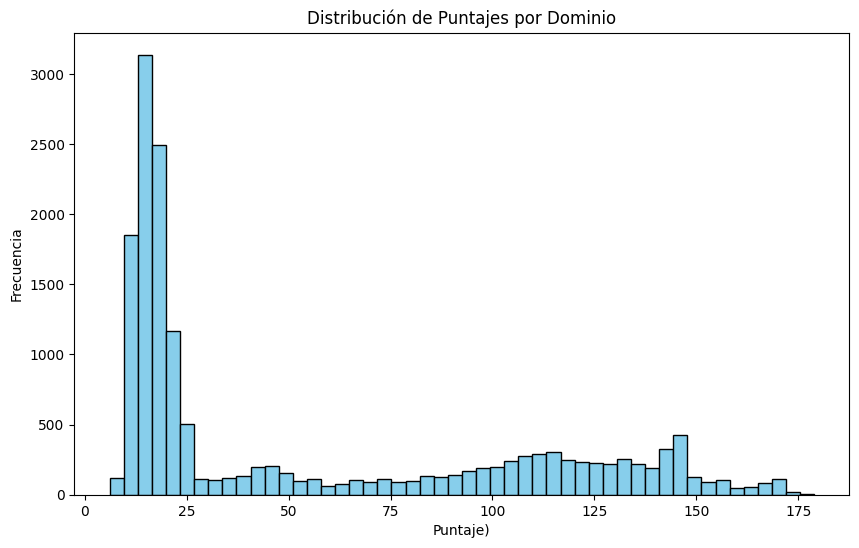

In [5]:
from Bio import SearchIO
from Bio import SeqIO
import matplotlib.pyplot as plt

resultados = SearchIO.read('Archivos/busqueda.out', 'hmmer3-text')
puntajesLista = []

for hit in resultados:
    for hsp in hit:
        puntajesLista.append(hsp.bitscore)

plt.figure(figsize=(10, 6))
plt.hist(puntajesLista, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Puntajes por Dominio')
plt.xlabel('Puntaje)')
plt.ylabel('Frecuencia')

plt.show()

### b) Desarrolle en python un código que utilice el puntaje de corte recién establecido para extraer los dominios búscados en las secuencias correspondientes.

Definimos un puntaje de corte de 40 viendo la distribución del histograma

In [15]:
from Bio import SearchIO
def extraerPosiciones(puntaje_corte):
    listaLimites = []
    
    for hit in resultados:
        for hsp in hit:
            if hsp.bitscore > puntaje_corte:
                listaLimites.append([hit.id, hsp.hit_start, hsp.hit_end]) 
                
    return listaLimites


def guardarDominios(listaLimites):
    registrosFasta = list(SeqIO.parse("Archivos/globin_full_sequences.fasta", "fasta"))
    registrosModificados = []
    
    for registro in registrosFasta:
        contador = 0
        coincidencia = False
        while not coincidencia and contador < len(listaLimites):
            idBuscado, inicio, fin = listaLimites[contador]
            
            # Si hay coincidencia entre el ID del Fasta y el de nuestra búsqueda
            if idBuscado == registro.id:
                coincidencia = True
                dominioRecortado = registro[inicio:fin]
                partesId = registro.id.split('|')
                uniprotId = partesId[1] if len(partesId) > 1 else registro.id                
                nuevoId = f"{uniprotId}/{inicio+1}-{fin}" 
                dominioRecortado.id = nuevoId                
                registrosModificados.append(dominioRecortado)
                
                listaLimites.pop(contador)
            
            else:
                contador += 1

    SeqIO.write(registrosModificados, "Archivos/dominios_protoglobina_recortados.fasta", "fasta")
    print(f"Se recuperaron y guardaron {len(registrosModificados)} dominios.")

limitesRecuperados = extraerPosiciones(40)
guardarDominios(limitesRecuperados)

Se recuperaron y guardaron 6473 dominios.


### c) Responda:
- __¿Cuántos dominios de protoglobina logró recuperar de la minería de datos?__  
Se lograron recuperar 6473 dominios de protoglobina
- __¿Puede afirmar que recuperó todos y que no dejó alguno afuera?__  
No es posible afirmarlo, la elección de un umbral de corte manual siempre implica un compromiso entre sensibilidad y especificidad. Al establecer un corte arbitrario de 40 para evitar incorporar ruido, aumentamos la especificidad, pero disminuimos la sensibilidad. Es altamente probable que secuencias de verdaderas protoglobinas que estén muy mutadas hayan quedado como falsos negativos.
- __¿O que solo recuperó dominios protoglobina y que no incorporó dominios globina de otro tipo? ¿Por qué?__  
Tampoco se puede afirmar, si existe una alta conservación de otras familias de globinas que compartan motivos muy similares con el perfil de la protoglobina, podrían haber superado el umbral de 40 puntos, incorporándose a nuestro set como falsos positivos